In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
for item in os.listdir("/content/drive/MyDrive/mura"):
    print(item)

Bone_Region_Identification.zip


In [3]:
import zipfile, os

ZIP_PATH    = "/content/drive/MyDrive/mura/Bone_Region_Identification.zip"
EXTRACT_DIR = "/content/dataset"

print("Zip açılıyor... (2-3 dakika sürebilir)")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)
print("Tamamlandı!")

# Yapıyı kontrol et
for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/ ({len(files)} files)")
    if level > 2:
        break

Zip açılıyor... (2-3 dakika sürebilir)
Tamamlandı!
dataset/ (0 files)
  Bone_Region_Identification/ (3 files)
    dataset_3/ (3 files)
    dataset_Mura_cleaned/ (0 files)
      train/ (0 files)


Device: cuda
Bozuk görüntüler temizleniyor...
Sınıflar: ['XR_ELBOW', 'XR_FINGER', 'XR_FOREARM', 'XR_HAND', 'XR_HUMERUS', 'XR_SHOULDER', 'XR_WRIST']
Train: 36808 | Val: 3197
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 132MB/s]



── Aşama 1: Frozen backbone ──
Epoch 1/5 — loss: 1.1895 | val_loss: 0.5118 | val_acc: 0.8768
Epoch 2/5 — loss: 0.8858 | val_loss: 0.4438 | val_acc: 0.8921
Epoch 3/5 — loss: 0.8345 | val_loss: 0.4241 | val_acc: 0.8946
Epoch 4/5 — loss: 0.8072 | val_loss: 0.3857 | val_acc: 0.9058
Epoch 5/5 — loss: 0.7949 | val_loss: 0.4027 | val_acc: 0.9062

── Aşama 2: Fine-tune ──
Epoch 1/12 — loss: 0.7380 | val_loss: 0.2658 | val_acc: 0.9443 ✅ Best!
Epoch 2/12 — loss: 0.6130 | val_loss: 0.2030 | val_acc: 0.9634 ✅ Best!
Epoch 3/12 — loss: 0.5641 | val_loss: 0.1895 | val_acc: 0.9675 ✅ Best!
Epoch 4/12 — loss: 0.5365 | val_loss: 0.1856 | val_acc: 0.9668
Epoch 5/12 — loss: 0.5248 | val_loss: 0.1824 | val_acc: 0.9690 ✅ Best!
Epoch 6/12 — loss: 0.5157 | val_loss: 0.1751 | val_acc: 0.9681
Epoch 7/12 — loss: 0.5080 | val_loss: 0.1783 | val_acc: 0.9681
Epoch 8/12 — loss: 0.4995 | val_loss: 0.1788 | val_acc: 0.9690
Epoch 9/12 — loss: 0.5009 | val_loss: 0.1768 | val_acc: 0.9675
Epoch 10/12 — loss: 0.4981 | val_

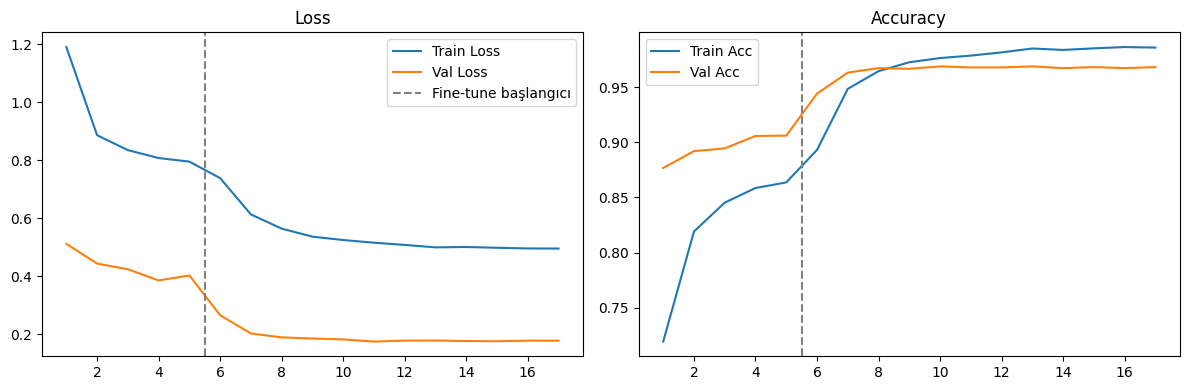


── Val seti sonuçları ──
              precision    recall  f1-score   support

    XR_ELBOW       0.95      0.98      0.96       465
   XR_FINGER       0.98      0.96      0.97       461
  XR_FOREARM       0.97      0.89      0.93       301
     XR_HAND       0.95      0.99      0.97       460
  XR_HUMERUS       0.97      0.94      0.96       288
 XR_SHOULDER       0.98      1.00      0.99       563
    XR_WRIST       0.98      0.98      0.98       659

    accuracy                           0.97      3197
   macro avg       0.97      0.96      0.96      3197
weighted avg       0.97      0.97      0.97      3197



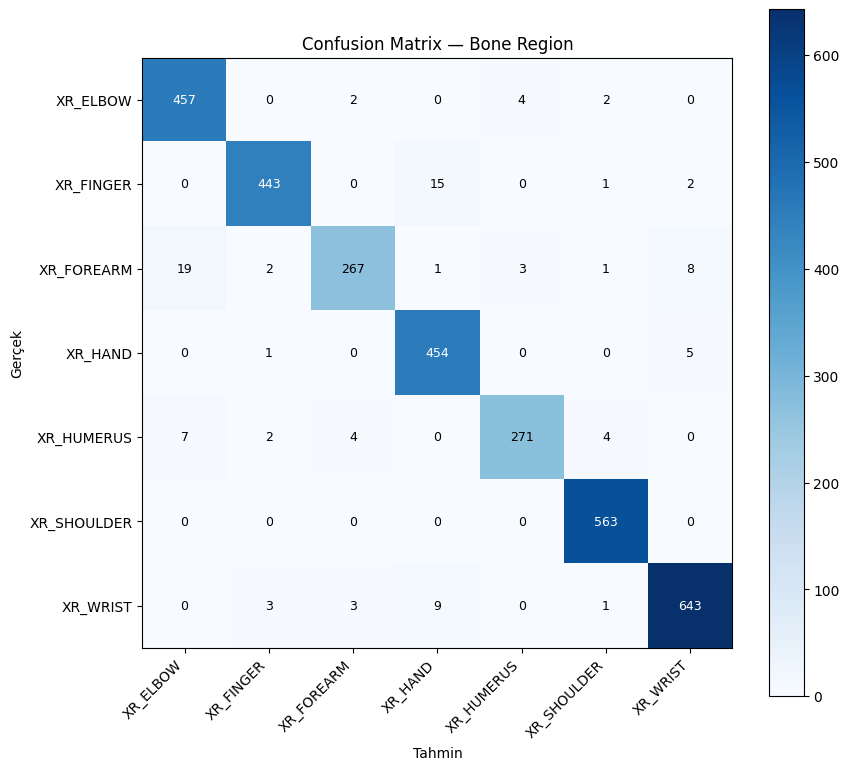

Tamamlandı! Model Drive'da.


In [4]:

# ──  Kütüphaneler ───────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from torchvision.datasets.folder import default_loader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
from PIL import ImageFile
from collections import Counter

ImageFile.LOAD_TRUNCATED_IMAGES = True

# ──  Config ─────────────────────────────────────────────
DATA_DIR= "/content/dataset/Bone_Region_Identification/dataset_Mura_cleaned"  # zip açılınca kontrol et
BATCH         = 64       # Colab GPU'da batch 64 kullan
EPOCHS_FROZEN = 5
EPOCHS_FT     = 12
LR_FROZEN     = 1e-3
LR_FT         = 3e-4
IMG_SIZE      = 224
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_PATH     = "/content/drive/MyDrive/bone_region_model.pth"  # Drive'a kaydet
print(f"Device: {DEVICE}")  # cuda çıkmalı!

# ── Transforms ─────────────────────────────────────────
train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.1)),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ─ Dataset ────────────────────────────────────────────
train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_tf)
val_ds   = datasets.ImageFolder(os.path.join(DATA_DIR, "valid"), transform=val_tf)

# Bozuk görüntüleri filtrele
def is_valid_image(path):
    try:
        default_loader(path)
        return True
    except:
        return False

print("Bozuk görüntüler temizleniyor...")
train_ds.samples = [(p, l) for p, l in train_ds.samples if is_valid_image(p)]
train_ds.targets = [l for p, l in train_ds.samples]
val_ds.samples   = [(p, l) for p, l in val_ds.samples if is_valid_image(p)]
val_ds.targets   = [l for p, l in val_ds.samples]

print(f"Sınıflar: {train_ds.classes}")
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

# ──  DataLoader ─────────────────────────────────────────
class_counts   = Counter(train_ds.targets)
total          = sum(class_counts.values())
class_weights  = {cls: total / count for cls, count in class_counts.items()}
sample_weights = [class_weights[label] for label in train_ds.targets]
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,   num_workers=2)

# ── Model ──────────────────────────────────────────────
model = models.efficientnet_b2(weights="IMAGENET1K_V1")
for param in model.parameters():
    param.requires_grad = False

in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, 512),
    nn.SiLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 7)
)
model = model.to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# ──  Train / Eval ───────────────────────────────────────
def train_one_epoch(loader, optimizer, scheduler=None):
    model.train()
    total_loss, correct = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if scheduler:
            scheduler.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

def evaluate(loader):
    model.eval()
    total_loss, correct = 0, 0
    crit = nn.CrossEntropyLoss()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out  = model(imgs)
            loss = crit(out, labels)
            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

# ──  Aşama 1: Frozen ───────────────────────────────────
print("\n── Aşama 1: Frozen backbone ──")
optimizer = AdamW(model.classifier.parameters(), lr=LR_FROZEN, weight_decay=1e-4)
scheduler = OneCycleLR(optimizer, max_lr=LR_FROZEN,
                       steps_per_epoch=len(train_loader),
                       epochs=EPOCHS_FROZEN, pct_start=0.3)
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0

for epoch in range(1, EPOCHS_FROZEN + 1):
    tl, ta = train_one_epoch(train_loader, optimizer, scheduler)
    vl, va = evaluate(val_loader)
    history["train_loss"].append(tl); history["val_loss"].append(vl)
    history["train_acc"].append(ta);  history["val_acc"].append(va)
    print(f"Epoch {epoch}/{EPOCHS_FROZEN} — loss: {tl:.4f} | val_loss: {vl:.4f} | val_acc: {va:.4f}")

# ──  Aşama 2: Fine-tune ────────────────────────────────
print("\n── Aşama 2: Fine-tune ──")
for param in model.parameters():
    param.requires_grad = True

optimizer = AdamW([
    {"params": model.features.parameters(), "lr": LR_FT / 10},
    {"params": model.classifier.parameters(), "lr": LR_FT},
], weight_decay=1e-4)
scheduler = OneCycleLR(optimizer, max_lr=[LR_FT / 10, LR_FT],
                       steps_per_epoch=len(train_loader),
                       epochs=EPOCHS_FT, pct_start=0.1)

for epoch in range(1, EPOCHS_FT + 1):
    tl, ta = train_one_epoch(train_loader, optimizer, scheduler)
    vl, va = evaluate(val_loader)
    history["train_loss"].append(tl); history["val_loss"].append(vl)
    history["train_acc"].append(ta);  history["val_acc"].append(va)
    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"Epoch {epoch}/{EPOCHS_FT} — loss: {tl:.4f} | val_loss: {vl:.4f} | val_acc: {va:.4f} ✅ Best!")
    else:
        print(f"Epoch {epoch}/{EPOCHS_FT} — loss: {tl:.4f} | val_loss: {vl:.4f} | val_acc: {va:.4f}")

print(f"\nEn iyi val_acc: {best_val_acc:.4f}")
print(f"Model Drive'a kaydedildi: {SAVE_PATH}")

# ──  Grafik ────────────────────────────────────────────
total_epochs = EPOCHS_FROZEN + EPOCHS_FT
epochs_range = range(1, total_epochs + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(epochs_range, history["train_loss"], label="Train Loss")
ax1.plot(epochs_range, history["val_loss"],   label="Val Loss")
ax1.axvline(x=EPOCHS_FROZEN + 0.5, color="gray", linestyle="--", label="Fine-tune başlangıcı")
ax1.set_title("Loss"); ax1.legend()
ax2.plot(epochs_range, history["train_acc"], label="Train Acc")
ax2.plot(epochs_range, history["val_acc"],   label="Val Acc")
ax2.axvline(x=EPOCHS_FROZEN + 0.5, color="gray", linestyle="--")
ax2.set_title("Accuracy"); ax2.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/training_curves_region.png", dpi=150)
plt.show()

# ──  Classification Report ─────────────────────────────
print("\n── Val seti sonuçları ──")
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        out  = model(imgs)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=train_ds.classes))

# ── 14. Confusion Matrix ──────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(7)); ax.set_yticks(range(7))
ax.set_xticklabels(train_ds.classes, rotation=45, ha="right")
ax.set_yticklabels(train_ds.classes)
for i in range(7):
    for j in range(7):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=9)
ax.set_xlabel("Tahmin"); ax.set_ylabel("Gerçek")
ax.set_title("Confusion Matrix — Bone Region")
plt.colorbar(im)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/confusion_matrix_region.png", dpi=150)
plt.show()
print("Tamamlandı! Model Drive'da.")